In [3]:
import os
import sys
import pandas as pd

# Ensure Python can import from ../src when running notebook from notebooks/
SRC_PATH = os.path.abspath("../src")
if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

from seniority import classify_seniority

# Load cleaned dataset (CSV fallback works reliably)
df = pd.read_csv("../data/job_postings_clean.csv")

# Apply seniority classification
# We use clean_text (combined title+description+etc, normalized) so the classifier
# can detect seniority cues even when the title is vague.
df["seniority"] = df["clean_text"].apply(classify_seniority)

print("Seniority distribution:")
print(df["seniority"].value_counts())

print("\nAs percentages:")
print((df["seniority"].value_counts(normalize=True) * 100).round(1))

# Save the full dataset with seniority labels 
df.to_csv("../data/job_postings_with_seniority.csv", index=False)

# Save one file per seniority level 
os.makedirs("../data", exist_ok=True)

for level in ["entry", "mid", "senior", "leadership"]:
    subset = df[df["seniority"] == level]
    out_path = f"../data/job_postings_{level}.csv"
    subset.to_csv(out_path, index=False)
    print(f"Saved {level}: {len(subset)} rows -> {out_path}")

Seniority distribution:
seniority
mid           1177703
senior         336990
entry           66576
leadership      34671
Name: count, dtype: int64

As percentages:
seniority
mid           72.9
senior        20.9
entry          4.1
leadership     2.1
Name: proportion, dtype: float64
Saved entry: 66576 rows -> ../data/job_postings_entry.csv
Saved mid: 1177703 rows -> ../data/job_postings_mid.csv
Saved senior: 336990 rows -> ../data/job_postings_senior.csv
Saved leadership: 34671 rows -> ../data/job_postings_leadership.csv


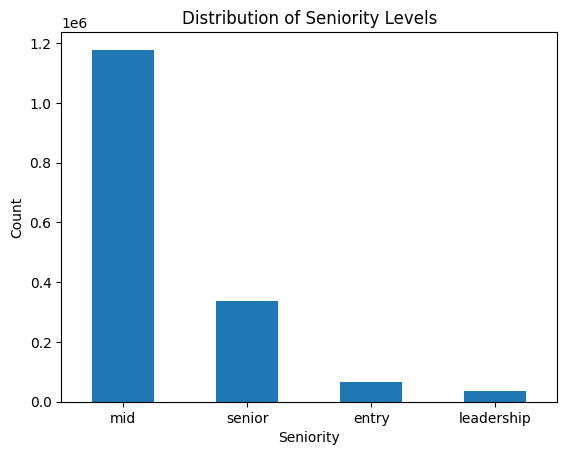

In [7]:
import matplotlib.pyplot as plt

counts = df["seniority"].value_counts()

plt.figure()
counts.plot(kind="bar")
plt.title("Distribution of Seniority Levels")
plt.xlabel("Seniority")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [8]:
# Word frequency per seniority
from collections import Counter

def get_top_words(text_series, n=20):
    words = " ".join(text_series).split()
    return Counter(words).most_common(n)

for level in ["entry", "mid", "senior", "leadership"]:
    print(f"\nTop words for {level}:")
    subset = df[df["seniority"] == level]
    print(get_top_words(subset["clean_text"], 15))


Top words for entry:
[('and', 266172), ('to', 129500), ('legal', 84018), ('administrative', 80576), ('assistant', 70108), ('years', 66576), ('in', 66557), ('support', 59591), ('provide', 52702), ('assist', 48950), ('with', 45593), ('managing', 42052), ('schedules', 41943), ('data', 38503), ('handle', 38479)]

Top words for mid:
[('and', 6322983), ('to', 2661090), ('years', 1177703), ('with', 889351), ('they', 733442), ('for', 645297), ('data', 623740), ('in', 614477), ('on', 607155), ('user', 552092), ('a', 486695), ('design', 475730), ('ensure', 461893), ('the', 458795), ('provide', 426592)]

Top words for senior:
[('and', 1706056), ('to', 729706), ('years', 336990), ('manager', 295235), ('the', 232507), ('with', 211450), ('they', 201261), ('a', 191495), ('manage', 187908), ('ensure', 180250), ('develop', 155575), ('sales', 153572), ('strategies', 146236), ('oversee', 135035), ('product', 128118)]

Top words for leadership:
[('and', 180455), ('to', 79674), ('marketing', 58725), ('bra

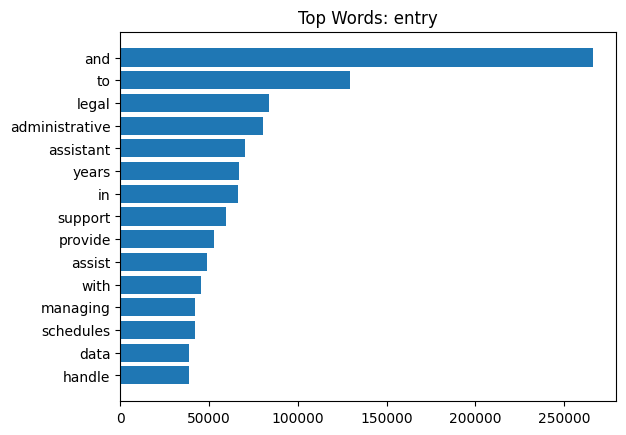

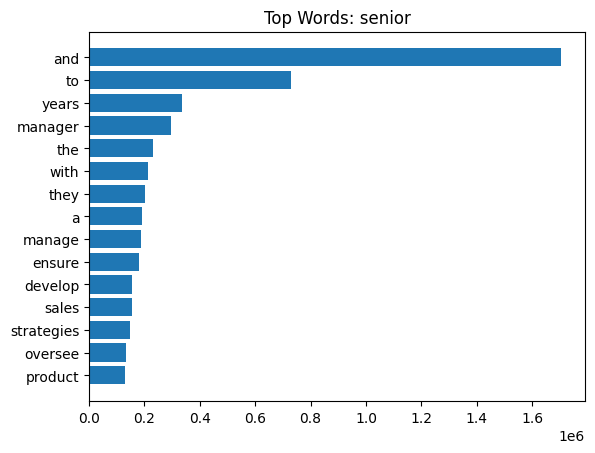

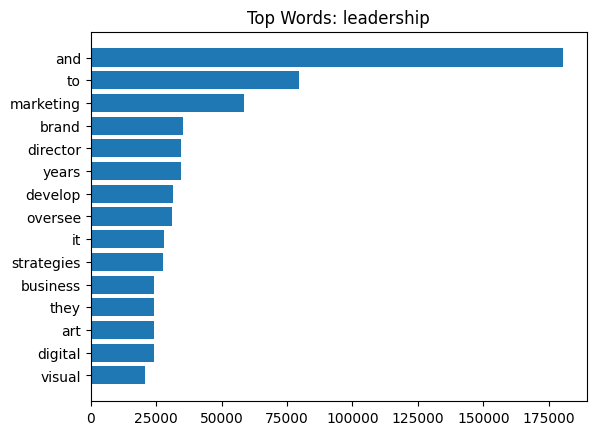

In [9]:
# Compare word distributions
def plot_top_words(level):
    subset = df[df["seniority"] == level]
    words = " ".join(subset["clean_text"]).split()
    top = Counter(words).most_common(15)

    words, counts = zip(*top)

    plt.figure()
    plt.barh(words, counts)
    plt.title(f"Top Words: {level}")
    plt.gca().invert_yaxis()
    plt.show()

for level in ["entry", "senior", "leadership"]:
    plot_top_words(level)